In [1]:
import os
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import geopandas as gpd
import osmnx as ox
import numpy as np
from scipy.spatial import cKDTree
from shapely import wkt
import contextily as cx

In [21]:
raw_data_path = os.path.join('../data/raw')

df_nodes = pd.read_csv(os.path.join(raw_data_path, 'nodes.csv'))
# df_nodes_with_poi_labels = pd.read_csv(os.path.join(dataset_path, 'nodes_with_poi_labels.csv'))
df_segments = pd.read_csv(os.path.join(raw_data_path, 'segments.csv'))
df_segment_status =pd.read_csv(os.path.join(raw_data_path, 'segment_status.csv'))
df_train = pd.read_csv(os.path.join(raw_data_path, 'train.csv'))

# Featuring
## 1. Crawl POIs from OSM

In [5]:
# 1. Download HCMC POIs & Traffic Features from OpenStreetMap
ox.settings.overpass_endpoint = "https://kumi.systems"
tags = {
    'amenity': True,   # Schools, hospitals, banks, parking
    'building': True,  # Offices, commercial plazas
    'tourism': True,   # Landmarks, parks
    'highway': ['traffic_signals', 'motorway_junction', 'bus_stop'] # Relevant for traffic data
}
print("Downloading HCMC POIs from OSM...")
pois_gdf = ox.features_from_place("Ho Chi Minh City, Vietnam", tags=tags)
print(pois_gdf.head(10))

/home/nhankuun2006/Documents/CSAI/project_01/.venv/lib64/python3.14/site-packages/osmnx/_overpass.py:271: UserWarning: This area is 22 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


                                     geometry amenity name ferry  \
element id                                                         
node    366053189  POINT (106.96623 10.40755)     NaN  NaN   NaN   
        366368730  POINT (106.73483 10.86865)     NaN  NaN   NaN   
        366370560  POINT (106.68861 10.79813)     NaN  NaN   NaN   
        366373362   POINT (106.68757 10.7986)     NaN  NaN   NaN   
        366375527  POINT (106.56189 10.86648)     NaN  NaN   NaN   
        366377788  POINT (106.76143 10.82631)     NaN  NaN   NaN   
        366378905  POINT (106.63543 10.76494)     NaN  NaN   NaN   
        366381386  POINT (106.68448 10.80331)     NaN  NaN   NaN   
        366382100  POINT (106.67161 10.79183)     NaN  NaN   NaN   
        366383451    POINT (106.706 10.75604)     NaN  NaN   NaN   

                  public_transport artwork_type tourism operator  \
element id                                                         
node    366053189              NaN          NaN

## 2. Save feature data into .csv file

In [ ]:
pois_gdf.to_csv(os.path.join(raw_data_path, 'pois.csv'), index=False)

## 3. Read shapely geometry from .csv file

In [ ]:
my_pois_df = pd.read_csv(os.path.join(raw_data_path, 'pois.csv'))
my_pois_df['geometry'] = my_pois_df['geometry'].apply(wkt.loads)
my_pois_gdf = gpd.GeoDataFrame(my_pois_df, geometry='geometry', crs="EPSG:4326")

/tmp/ipykernel_6497/463240077.py:1: DtypeWarning: Columns (0: amenity, 1: name, 2: ferry, 3: public_transport, 4: artwork_type, 5: tourism, 6: operator, 7: highway, 8: name:en, 9: ref, 10: denomination, 11: religion, 12: fixme, 13: phone, 14: delivery, 15: mobile, 16: opening_hours, 17: brand, 18: atm, 19: bus, 20: addr:housenumber, 21: addr:street, 22: internet_access, 23: name:fr, 24: name:vi, 25: email, 26: name:cs, 27: addr:postcode, 28: website, 29: cuisine, 30: addr:city, 31: addr:district, 32: addr:province, 33: addr:subdistrict, 34: internet_access:fee, 35: outdoor_seating, 36: emergency, 37: healthcare, 38: description:en, 39: diet:fish, 40: building, 41: grades, 42: education, 43: name:de, 44: office, 45: man_made, 46: diet:vegetarian, 47: name:ko, 48: currency:VND, 49: smoking, 50: payment:cash, 51: wheelchair, 52: description, 53: diet:vegan, 54: takeaway, 55: traffic_signals, 56: drinking_water, 57: backrest, 58: lit, 59: source, 60: fee, 61: name:zh, 62: name:ja, 63: name

## 4. Apply POIs from OSM to nodes in the road network

In [ ]:
# change all "yes" values to the column name
for col in ['amenity', 'highway', 'building', 'tourism']:
    my_pois_gdf[col] = my_pois_gdf[col].apply(lambda x: col if x == 'yes' else x)

tags_cols = ['amenity', 'highway', 'building', 'tourism']
my_pois_gdf['label'] = my_pois_gdf[tags_cols].bfill(axis=1).iloc[:, 0]
my_pois_gdf.to_csv(os.path.join(raw_data_path, 'pois_with_labels.csv'), index=False)

In [19]:
# 2. Keep the 'name' column, but fill missing ones with "Unknown"
my_pois_gdf['name'] = my_pois_gdf['name'].fillna("Unknown")

# 3. Drop rows that have absolutely no category label
my_pois_gdf = my_pois_gdf[my_pois_gdf['label'].notnull()].copy()

# 4. Project CRS and extract arrays for KD-Tree
my_pois_gdf = my_pois_gdf.to_crs(epsg=32648)  # Convert to UTM zone 48N for HCMC
poi_coords = np.array([(geom.centroid.x, geom.centroid.y) for geom in my_pois_gdf.geometry])
tree = cKDTree(poi_coords)

# Extract feature arrays
poi_names = my_pois_gdf['name'].values
poi_labels = my_pois_gdf['label'].values

nodes_gdf = gpd.GeoDataFrame(
    df_nodes, geometry=gpd.points_from_xy(df_nodes['long'], df_nodes['lat']), crs="EPSG:4326"
).to_crs(epsg=32648)
node_coords = np.array([(geom.x, geom.y) for geom in nodes_gdf.geometry])

# query the nearest POI for each node
distances, indices = tree.query(node_coords, k=1, workers=-1)

# 5. Assign both columns to df_nodes
df_nodes['poi_name'] = poi_names[indices]
df_nodes['poi_label'] = poi_labels[indices]
df_nodes['distance_meters'] = np.round(distances, 2)

MAX_DISTANCE = 50 # meters (adjust based on HCMC density)

# Find rows where the nearest POI is too far away
mask_too_far = df_nodes['distance_meters'] > MAX_DISTANCE

# Overwrite those labels to represent general roads/background
df_nodes.loc[mask_too_far, 'poi_name'] = 'None'
df_nodes.loc[mask_too_far, 'poi_label'] = 'Background'

In [11]:
# TEST
save_data_path = os.path.join('../data/processed')
df_nodes.to_csv(os.path.join(save_data_path, 'nodes_with_poi_labels.csv'), index=False)

# EDA kaggle dataset
## 1. check unique node

In [14]:
print(df_nodes.shape)
df_nodes_drop_duplicates = df_nodes.drop_duplicates(subset=['long', 'lat'], keep='first')
print(df_nodes_drop_duplicates.shape)

(577967, 3)
(577892, 3)


there are 75 duplicate nodes need to be removed

Visualize the distribution of total of nodes on a scatter map

/home/nhankuun2006/Documents/CSAI/project_01/.venv/lib64/python3.14/site-packages/contextily/tile.py:680: UserWarning: The inferred zoom level of 28 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)


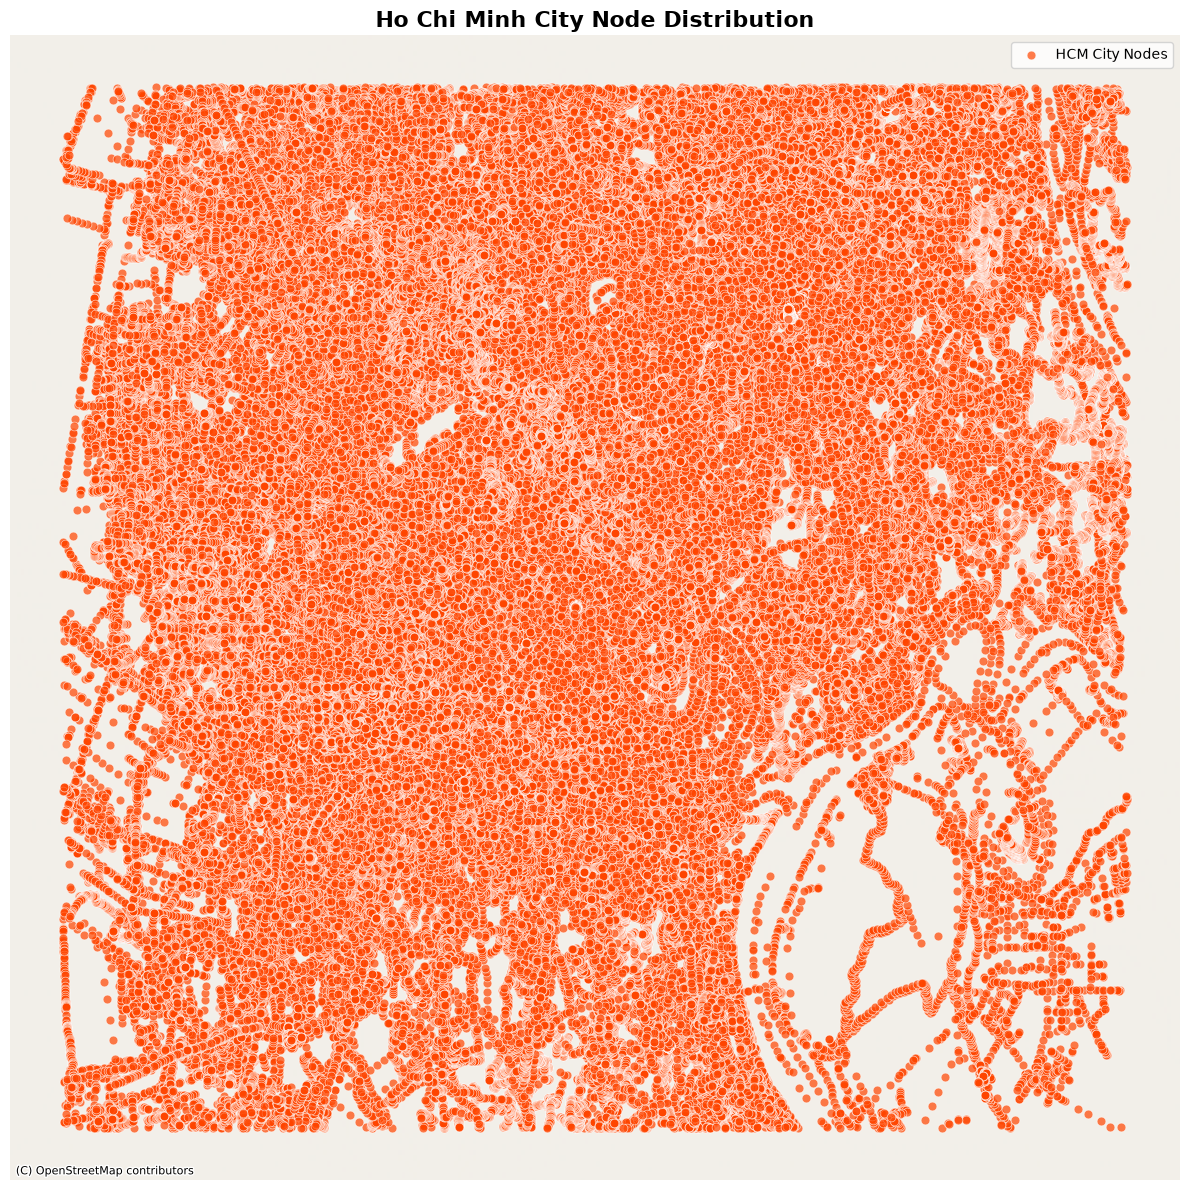

In [7]:
# 2. Setup the plot canvas
fig, ax = plt.subplots(figsize=(12, 12))

# 3. Plot the projected nodes using Seaborn
sns.scatterplot(
    data=df_nodes,
    x="long",
    y="lat",
    color="#FF4500",  # Vibrant orange-red pin color
    s=40,  # Marker size
    alpha=0.7,  # Transparency for overlapping points
    ax=ax,
    label="HCM City Nodes",
)

# 4. Add the OpenStreetMap background matching your UTM zone
cx.add_basemap(
    ax,
    crs="EPSG:32648",  # Match your coordinate reference system exactly
    source=cx.providers.OpenStreetMap.Mapnik,
)

# 5. Fine-tune layout decorations
ax.set_title("Ho Chi Minh City Node Distribution", fontsize=16, fontweight="bold")
ax.axis("off")  # Hides the raw UTM meter axis numbers for a clean map look
plt.legend(loc="upper right")

# 6. Render the map
plt.tight_layout()
plt.show()

## 2. segments
### check unique segments

In [13]:
print("segments.csv shape:")
print(df_segments.shape)
df_segments_drop_duplicates = df_segments.drop_duplicates(subset=['s_node_id', 'e_node_id'], keep='first')
print("segments.csv shape after dropping duplicates:")
print(df_segments_drop_duplicates.shape)

print("\nsegment_status.csv shape:")
print(df_segment_status.shape)

segments.csv shape:
(84633, 12)
segments.csv shape after dropping duplicates:
(84629, 12)

segment_status.csv shape:
(90938, 5)


- There are 4 duplicate segments need to be removed

check max segment_id in segment_status.csv and train.csv, they are the same, so we can use segment_status.csv to get the status of segments in train.csv

In [13]:
print(max(df_segment_status['segment_id']))
print(max(df_train['segment_id']))

84535
84535


In [25]:
# Select distint
df_distinct_segment_status = df_segment_status.drop_duplicates(subset=['segment_id'], keep='first')
df_distinct_train = df_train.drop_duplicates(subset=['segment_id'], keep='first')

print(df_distinct_segment_status.shape)
print(df_distinct_train.shape)

df_seg_train = pd.merge(df_distinct_segment_status, df_distinct_train, on='segment_id', how='outer')
print(df_seg_train.shape)
df_seg_train = pd.merge(df_distinct_segment_status, df_distinct_train, on='segment_id', how='inner')
print(df_seg_train.shape)

(10027, 4)
(10027, 18)
(10027, 21)
(10027, 21)


In [23]:
df_seg_train = pd.merge(df_distinct_segment_status, df_distinct_train, on='segment_id', how='left')
print(df_seg_train.shape)

(10027, 21)


CONCLUDE: 1 - 1 relationship

In [12]:
# filter segment measured in 2021:
print("filter segment_status measured in 2021:")
df_segment_status['updated_at_year'] = df_segment_status['updated_at'].apply(lambda x: int(x[0:4]))
df_segment_status_2021 = df_segment_status[df_segment_status['updated_at_year'] == 2021].drop_duplicates(subset=['segment_id'], keep='first').shape
print(df_segment_status_2021)

print("filter segment measured in 2021:")
df_segments['updated_at_year'] = df_segments['updated_at'].apply(lambda x: int(x[0:4]))
df_segments_2021 = df_segments[df_segments['updated_at_year'] == 2021].drop_duplicates(subset=['_id'], keep='first').shape
print(df_segments_2021)

filter segment_status measured in 2021:
(3137, 5)
filter segment measured in 2021:
(19202, 12)


### check non-positive length segments

In [22]:
print(df_segments.describe())
print(df_segments[df_segments['length'] <= 0].shape)

                _id     s_node_id     e_node_id        length     street_id  \
count  84633.000000  8.463300e+04  8.463300e+04  84633.000000  8.463300e+04   
mean   42316.000000  3.674041e+09  3.672725e+09     41.818050  2.866904e+08   
std    24431.587003  2.039756e+09  2.040056e+09     52.692336  2.085526e+08   
min        0.000000  3.663672e+08  3.663672e+08      0.000000  3.109679e+07   
25%    21158.000000  2.078951e+09  2.078951e+09     13.000000  3.511357e+07   
50%    42316.000000  4.068031e+09  4.068031e+09     27.000000  2.517313e+08   
75%    63474.000000  5.748273e+09  5.748270e+09     52.000000  4.693276e+08   
max    84632.000000  6.175932e+09  6.175932e+09   1622.000000  6.583281e+08   

       max_velocity  street_level  updated_at_year  
count   9871.000000  84633.000000     84633.000000  
mean      54.503596      3.500006      2020.226885  
std       16.553367      0.841222         0.418820  
min       10.000000      1.000000      2020.000000  
25%       40.000000    

There are 154 segments with non-positive length, which is not valid. We need to remove them from the dataset.

## 3. Analyze correlation between LOS and actual velocity in train.csv & segment_status.csv

In [13]:
# 1. Đọc dữ liệu
train = pd.read_csv(os.path.join(raw_data_path, 'train.csv'))
status = pd.read_csv(os.path.join(raw_data_path, 'segment_status.csv'))

# 2. Chuẩn hóa ngày và khung giờ (period) để nối dữ liệu
status['updated_at'] = pd.to_datetime(status['updated_at'])
status['date_str'] = status['updated_at'].dt.strftime('%Y-%m-%d')

def get_period(dt):
    if dt.minute <= 15:
        minute = 0
    elif dt.minute <= 45:
        minute = 30
    else:
        minute = 0
        dt += pd.Timedelta(hours=1)  # Move to the next hour if past 45 minutes
        
    return f"period_{dt.hour}_{minute:02d}"

status['period'] = status['updated_at'].apply(get_period)
train['date_str'] = pd.to_datetime(train['date']).dt.strftime('%Y-%m-%d')

# 3. Nối (JOIN) train và segment_status
train_status = pd.merge(train, status, on=['segment_id', 'date_str', 'period'], how='inner')

# 4. Lọc bỏ vận tốc vô lý (nếu có) và tính toán thống kê
valid_data = train_status[(train_status['velocity'] >= 0) & (train_status['velocity'] <= 100)]
los_summary = valid_data.groupby('LOS')['velocity'].agg(
    So_luong_mau='count',
    Van_toc_TB='mean',
    Van_toc_Trung_vi='median',
    Do_lech_chuan='std'
).reindex(['A', 'B', 'C', 'D', 'E', 'F'])

# 5. Tính tỷ lệ so với LOS A
v_A = los_summary.loc['A', 'Van_toc_TB']
los_summary['Ty_le_toc_do_so_voi_A'] = (los_summary['Van_toc_TB'] / v_A).map('{:.1%}'.format)
los_summary['He_so_tang_thoi_gian'] = (v_A / los_summary['Van_toc_TB']).map('{:.2f}x'.format)

print("--- BẢNG THỐNG KÊ THAM SỐ QUY ĐỔI LOS TỪ DỮ LIỆU THỰC TẾ ---")
display(los_summary)

# 6. Tạo dictionary cho các hệ số rủi ro dựa trên LOS
risk_dict_calculated = los_summary['He_so_tang_thoi_gian'].str.rstrip('x').astype(float).to_dict()

# 7. map to the dataset
train['congestion_factor'] = train['LOS'].map(risk_dict_calculated)

# 8. Save
train.to_csv(os.path.join(save_data_path, 'processed_train.csv'), index=False)

--- BẢNG THỐNG KÊ THAM SỐ QUY ĐỔI LOS TỪ DỮ LIỆU THỰC TẾ ---


,So_luong_mau,Van_toc_TB,Van_toc_Trung_vi,Do_lech_chuan,Ty_le_toc_do_so_voi_A,He_so_tang_thoi_gian
LOS,,,,,,
A,8684,51.955435,49.0,12.148624,100.0%,1.00x
B,3322,33.442806,34.0,4.084313,64.4%,1.55x
C,5340,25.902809,28.0,11.817164,49.9%,2.01x
D,9534,20.635515,21.0,11.062359,39.7%,2.52x
E,6862,15.243078,15.0,10.142725,29.3%,3.41x
F,24151,2.275020,1.0,3.632242,4.4%,22.84x


## 4. Analyze correlation between street_level and actual velocity in train.csv & segment_status.csv

In [15]:
# 1. Calculate velocity statistics grouped by 'street_level'
risk_summary = valid_data.groupby('street_level')['velocity'].agg(
    So_luong_mau='count',
    Van_toc_TB='mean',
    Van_toc_Trung_vi='median',
    Do_lech_chuan='std'
).sort_index()

# 2. Method A: Risk Factor based on velocity ratio
# Baseline: The street_level with the highest average velocity (safest/fastest road)
v_baseline = risk_summary['Van_toc_TB'].max()
# Slower roads get a higher risk factor
risk_summary['Velocity_Risk_Factor'] = v_baseline / risk_summary['Van_toc_TB']

# 3. Method B: Risk Factor based on Volatility (Coefficient of Variation)
# CV = Std / Mean. Higher CV means traffic is more chaotic and unpredictable.
risk_summary['CV_Volatility'] = risk_summary['Do_lech_chuan'] / risk_summary['Van_toc_TB']
# Normalize relative to the most stable road
min_cv = risk_summary['CV_Volatility'].min()
risk_summary['Volatility_Risk_Factor'] = risk_summary['CV_Volatility'] / min_cv

# 4. Combined Risk Factor
# average both risks to get a robust risk factor
risk_summary['Combined_Risk_Factor'] = (risk_summary['Velocity_Risk_Factor'] + risk_summary['Volatility_Risk_Factor']) / 2

print("--- RISK FACTOR ANALYSIS BY STREET LEVEL ---")
display(risk_summary)

# 5. generate the risk dictionary
risk_dict_calculated = risk_summary['Combined_Risk_Factor'].round(3).to_dict()

print("\n# Copy this generated dictionary into your routing algorithm:")
print("risk_dict =", risk_dict_calculated)

# 6. map to the dataset
train['risk_factor'] = train['street_level'].map(risk_dict_calculated)

# 7. save
train.to_csv(os.path.join(save_data_path, 'processed_train.csv'), index=False)

--- RISK FACTOR ANALYSIS BY STREET LEVEL ---


,So_luong_mau,Van_toc_TB,Van_toc_Trung_vi,Do_lech_chuan,Velocity_Risk_Factor,CV_Volatility,Volatility_Risk_Factor,Combined_Risk_Factor
street_level,,,,,,,,
1,1552,36.657216,48.0,19.001368,1.000000,0.518353,1.000000,1.000000
2,19216,16.977727,7.0,18.540300,2.159136,1.092037,2.106744,2.132940
3,5231,26.163831,24.0,19.860828,1.401065,0.759095,1.464437,1.432751
4,31894,16.833292,9.0,18.841119,2.177662,1.119277,2.159296,2.168479



# Copy this generated dictionary into your routing algorithm:
risk_dict = {1: 1.0, 2: 2.133, 3: 1.433, 4: 2.168}


# TESTING

- calculate actual velocity based on LOS
- calculate time based on actual velocity and length

In [17]:
# LOS dictionary
LOS_dict = {
    'A': 1.0,
    'B': 1.55,
    'C': 2.01,
    'D': 2.52,
    'E': 3.41,
    'F': 22.84
}

# train['actual_velocity'] = train['LOS'].map(LOS_dict).apply(lambda los: 18 / los)  # v_max = 18 m/s
train['actual_velocity'] = 18 / train['congestion_factor']  # v_max = 18 m/s
train['time'] = train['length'] / train['actual_velocity']  # time in seconds
train.to_csv(os.path.join(save_data_path, 'full_processed_train.csv'), index=False)

In [ ]:
# Risk dictionary based on street_level (1-4) and corresponding risk factors
risk_dict = {
    1: 1.0,
    2: 2.133,
    3: 1.433,
    4: 2.168
}

In [19]:
# filter column for processed_train.csv
columns_to_export = [
    'segment_id', 
    's_node_id', 
    'e_node_id', 
    'actual_velocity',
    'time', 
    'congestion_factor',
    'risk_factor'
]
# Export to CSV
train[columns_to_export].to_csv(os.path.join(save_data_path, 'processed_train.csv'), index=False)

# 5. Find parameters for cost function using AHP (analytic hierarchy process)

In [20]:
import numpy as np

# 1. Define the pairwise comparison matrix
# Order: [Time, Congestion, Risk]
matrix = np.array([
    [1.0,  3.0,  5.0],
    [1/3,  1.0,  2.0],
    [1/5,  1/2,  1.0]
])

# 2. Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(matrix)

# 3. Find the principal eigenvalue (the largest one)
max_index = np.argmax(eigenvalues.real)

# 4. Extract the principal eigenvector
principal_eigenvector = eigenvectors[:, max_index].real

# 5. Normalize the vector so a + b + c = 1.0
weights = principal_eigenvector / np.sum(principal_eigenvector)

a, b, c = weights

print(f"Time Weight (a): {a:.3f}")
print(f"Congestion Weight (b): {b:.3f}")
print(f"Risk Weight (c): {c:.3f}")

# 6. export to json


Time Weight (a): 0.648
Congestion Weight (b): 0.230
Risk Weight (c): 0.122
